1. Lib & Data Imports

In [6]:
import boto3
import pandas as pd
import numpy as np
import numpy as np
from scipy.stats import poisson

# Initialize the S3 client
s3 = boto3.client('s3')

# Download a file from S3
bucket_name = "alpha-research-high-frequency-prediction" 
file_key = "first_25000_rows.csv"  # Path in S3 bucket
local_path = "./first_25000_rows.csv"  # Path on local machine

s3.download_file(bucket_name, file_key, local_path)
print("File downloaded successfully!")


File downloaded successfully!


In [47]:
df = pd.read_csv('./first_25000_rows.csv') # DATA INPUT HERE
print('--------------------------------------------------------------')
print(f"Input dataframe head: {df.head()}") 
print('--------------------------------------------------------------')
print(f" Input Dataframe Columns: {df.columns}")
print('--------------------------------------------------------------')
print(f"full data: {df}")

# Start of pre-processing
# Organize dates and timestamps
df['ts_event'] = pd.to_datetime(df['ts_event'], utc=True) # time standard
df = df.sort_values('ts_event').reset_index(drop=True) # date sort
df['Timestamp'] = pd.to_datetime(df['ts_event'])
df['Date'] = df['Timestamp'].dt.date

#market_open_time = pd.to_datetime('13:30:00').time()  # Market opens at 13:30:00
#market_close_time = pd.to_datetime('20:00:00').time()  # Market closes at 19:59:59

df.set_index('ts_event', inplace=True)
#df_market = df.copy().between_time(market_open_time, market_close_time)

# Rename a specific column
df.rename(columns={'bid_px_00': 'best_bid'}, inplace=True)
df.rename(columns={'ask_px_00': 'best_ask'}, inplace=True)


# Aggregation
# IMPORTANT: CHANGE FREQUENCY HERE
df_minute = df.resample('1min').agg({
    'best_bid': 'max',
    'best_ask': 'min'
})
df_minute['spread'] = df_minute['best_ask'] - df_minute['best_bid']
df_minute = df_minute.dropna(subset=['best_bid']) # downsample will fill NaNs to out-of-market hours
df_minute = df_minute.reset_index()
df_minute['mid_price'] = df_minute['best_ask'] + (df_minute['best_ask'] - df_minute['best_bid']) / 2
print(f"Minute aggregated data head: \n {df_minute.head()}")
print('--------------------------------------------------------------')
print(f"Minute aggregated data shape: {df_minute.shape}")
print('--------------------------------------------------------------')

--------------------------------------------------------------
Input dataframe head:                           ts_recv                        ts_event  rtype  \
0  2024-10-21T11:54:29.221230963Z  2024-10-21T11:54:29.221064336Z     10   
1  2024-10-21T11:54:29.223936626Z  2024-10-21T11:54:29.223769812Z     10   
2  2024-10-21T11:54:29.225196809Z  2024-10-21T11:54:29.225030400Z     10   
3  2024-10-21T11:54:29.712600612Z  2024-10-21T11:54:29.712434212Z     10   
4  2024-10-21T11:54:29.764839221Z  2024-10-21T11:54:29.764673165Z     10   

   publisher_id  instrument_id action side  depth   price  size  ...  \
0             2             38      C    B      1  233.62     2  ...   
1             2             38      A    B      0  233.67     2  ...   
2             2             38      A    B      0  233.67     3  ...   
3             2             38      A    B      2  233.52   200  ...   
4             2             38      C    B      2  233.52   200  ...   

   ask_sz_08  bid_ct_08  

## Calculating Outflows

First we need to implement logic for counting outflow in our data. We will count total shares for cancellations and executions at the Queue price. We will do this for each minute in the data, and average over all the minutes. This will give us a typical outflow/min.

We can then use this value to simulate additional venues using a Poisson distribution ξk = αξ0 + (1 − α)k where ξ0, k are i.i.d. Poisson random variables with a common mean parameter µT. 





In [54]:
# Function to calculate queue size and outflow fills for a time interval
def calculate_outflow_fills_for_interval(df, p):
    """
    Calculate queue size (Q) and outflow fills (x_i) for a single time interval
    :param df: DataFrame containing L2 data for a single time interval
    :param p: The order price (highest best bid across all venues)
    :return: A dictionary with queue size Q and outflow fill
    """
    # Identify the first timestamp row in the interval
    first_row = df.iloc[0]
    if p == first_row['best_bid']:
        Q = first_row['best_bid_depth']  # Use bid depth from the first row if price matches best bid
    else:
        Q = 0  # Otherwise, Q is 0. (best_ask > p > best_bid)

    # Calculate outflow fills
    if Q == 0:
        # If Q is 0, outflow fills include executed orders with price < p
        outflow_fill = df[ ( df['price'] < p ) & (df['action'] == 'T') ]['size'].sum()
    else:
        # If Q > 0, outflow fills include:
        # 1. Canceled orders at price p
        # 2. Executed orders with price <= p
        cancellations = df[(df['price'] == p) & (df['action'] == 'C')]['size'].sum()
        executed = df[(df['price'] <= p) & (df['action'] == 'T')]['size'].sum()
        outflow_fill = cancellations + executed

    return {'Q': Q, 'outflow_fill': outflow_fill}

# Function to calculate queue size and outflow fills for all intervals
def calculate_outflow_fills_all_intervals(dataframes, p):
    """
    Calculate queue size (Q) and outflow fills (x_i) for all intervals across venues
    :param dataframes: A dictionary where keys are venue names and values are DataFrames
    :param p: The order price (highest best bid across all venues)
    :return: DataFrame containing results for all venues and intervals
    """
    results = []
    for venue, df in dataframes.items():
        # Group data by 1-minute intervals
        df['interval'] = df['timestamp'].dt.floor('1min')  # Floor timestamps to the nearest minute
        grouped = df.groupby('interval')

        for interval, group in grouped:
            # Calculate outflow fills for the current interval
            result = calculate_outflow_fills_for_interval(group, p)
            result['venue'] = venue
            result['interval'] = interval
            results.append(result)

    return pd.DataFrame(results)

# Each value best_bid_list[i] in the list is the best bid for the ith time step
best_bid_list = df.groupby('ts_event')['best_bid'].max().tolist()
print(f"Best bid list is: {best_bid_list}")

outflows = []
dataframes = {'NASDAQ': df}

for bid in best_bid_list:
    outflows.append(calculate_outflow_fills_all_intervals(dataframes, bid))


# Calculate queue size and outflow fills for all venues and 1-minute intervals
    

# Display Results
print("\nSample Generated L2 Data:")
print(dataframes['NASDAQ'].head())

print("\nQueue Size and Outflow Fills Results:")
print(results.head())

p is: [233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.7, 233.7, 233.7, 233.7, 233.7, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.55, 233.67, 233.55, 233.54, 233.54, 233.54, 233.54, 233.54, 233.54, 233.55, 233.55, 233.55, 233.55, 233.55, 233.55, 233.55, 233.55, 233.55, 233.55, 233.55, 233.55, 233.55, 233.53, 233.56, 233.56, 233.56, 233.56, 233.56, 233.56, 233.56, 233.56, 233.56, 233.56, 233.56, 233.53, 233.57, 233.57, 233.57, 233.57, 233.57, 233.57, 233.57, 233.57, 233.57, 233.57, 233.57, 233.57, 233.53, 233.58, 233.58, 233.58, 233.58, 233.58, 233.58, 233.58, 233.58, 233.58, 233.58, 233.58, 233.58, 233.58, 233.58, 233.58, 233.58, 233.58, 233.58, 233.58, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67, 233.67

KeyError: 'timestamp'

In [48]:
def generate_order_outflows(num_exchanges, num_samples, mu=2200, T=1, alpha=0.6):
    """
    Generate correlated order outflows for multiple exchanges using a single-factor model
    
    Parameters:
    -----------
    num_exchanges : int
        Number of exchanges to generate outflows for
    num_samples : int
        Number of samples to generate
    mu : float
        Mean arrival rate (shares per minute)
    T : float
        Time interval in minutes
    alpha : float
        Correlation factor between exchanges (0 to 1)
        
    Returns:
    --------
    numpy.ndarray
        Array of shape (num_samples, num_exchanges) containing order outflows
    """
    # Calculate mean for the Poisson distributions
    mean = mu * T
    
    # Generate common factor ξ0 (shared across all exchanges)
    xi_0 = poisson.rvs(mean, size=num_samples)
    
    # Initialize array to store results
    outflows = np.zeros((num_samples, num_exchanges))
    
    # Generate outflows for each exchange
    for k in range(num_exchanges):
        # Generate independent Poisson variables εk for this exchange
        epsilon_k = poisson.rvs(mean, size=num_samples)
        
        # Combine using the single-factor model
        outflows[:, k] = alpha * xi_0 + (1 - alpha) * epsilon_k
        
    return outflows

# Example usage and testing
if __name__ == "__main__":
    # Parameters from the paper
    NUM_EXCHANGES = 2
    NUM_SAMPLES = 1000
    MU = 2200  # shares per minute
    T = 1      # minute
    ALPHA = 0.6
    
    # Generate outflows
    outflows = generate_order_outflows(NUM_EXCHANGES, NUM_SAMPLES, MU, T, ALPHA)
    
    # Print some statistics
    print("\nOrder Outflow Statistics:")
    print("-----------------------")
    print(f"Number of samples: {NUM_SAMPLES}")
    print(f"Number of exchanges: {NUM_EXCHANGES}")
    print(f"Theoretical mean (μT): {MU * T}")
    
    for k in range(NUM_EXCHANGES):
        print(f"\nExchange {k+1}:")
        print(f"Mean outflow: {outflows[:, k].mean():.2f}")
        print(f"Std outflow: {outflows[:, k].std():.2f}")
    
    # Calculate and print correlation between exchanges
    if NUM_EXCHANGES >= 2:
        correlation = np.corrcoef(outflows[:, 0], outflows[:, 1])[0, 1]
        print(f"\nCorrelation between exchange 1 and 2: {correlation:.3f}")


Order Outflow Statistics:
-----------------------
Number of samples: 1000
Number of exchanges: 2
Theoretical mean (μT): 2200

Exchange 1:
Mean outflow: 2200.53
Std outflow: 35.00

Exchange 2:
Mean outflow: 2199.96
Std outflow: 34.82

Correlation between exchange 1 and 2: 0.716


In [ ]:
# Number of venues
K = 1

# Venue market order fees
fees = {
    'NASDAQ': 0.001,
    'NYSE': 0.002,
    'IEX': 0.0015
}

# Limit order rebates
rebates = {
    'NASDAQ': 0.001,
    'NYSE': 0.002,
    'IEX': 0.0015
}


    
# Outflows xi







2. Data Preprocessing

(Output of this should be a DF that is correctly formatted that can be directly input to the following algo.)

3. Venue Specific Detials

4. Model Parameter Definitions

Propositions:
![proposition1](proposition1.png)

Function A:
![Function_A](Function_A.png)


Cost Function:
![Formula](Formula.png)


Objective Function:
![Objective](Objective.png)

Adverse Selection: $$r_k = r_k^e + A S_k$$


Constraints:
![Constraints](Constraints.png)

In [7]:
def calculate_filled_amounts(Q, L, xi):
    """
    Calculate filled amounts for limit orders based on queue outflows.
    Parameters:
    M (np.array): Market Quantity
    Q (np.array): Queue sizes at each exchange
    L (np.array): Limit order sizes at each exchange
    xi (np.array): Order outflows at each exchange
    Returns:
    np.array: Amount filled at each exchange
    """
   
    return np.maximum(xi - Q, 0) - np.maximum(xi - Q - L, 0)


def cost_func(X, xi, params):
    """
    Calculate the cost v(X,ξ) as defined in equation (5) of the paper.
    Parameters:
    X: Order allocation vector (M, L1,...,LK)
        M: Market order size
        L1...LK: Limit order sizes for K exchanges
    xi: Order outflow vector (ξ1,...,ξK)
    
    params: Dictionary containing:
        h: Half spread
        f: Market order fee
        r: Array of effective rebates for each exchange
        theta: Market impact coefficient
        lambda_u: Underfill penalty
        lambda_o: Overfill penalty
        Q: Array of queue sizes at each exchange
        S: Target quantity
    Returns:
    float: Total cost
    """
    M = X[0]  # Market order size
    L = X[1:] # Limit order sizes
    # Calculate total filled amounts for limit orders
    filled_amounts = calculate_filled_amounts(params['Q'], L, xi)
    total_filled = M + np.sum(filled_amounts)  # Function A of the Paper
    
    S = params['S']
    # Calculate explicit trading costs
    market_cost = (params['h'] + params['f']) * M
    limit_costs = -np.sum((params['h'] + params['r']) * filled_amounts)
    
    # Calculate market impact
    total_orders = M + np.sum(L)
    catch_up = max(S - total_filled, 0)  # Additional market orders needed
    impact = params['theta'] * (total_orders + catch_up)
    
    # Calculate shortfall penalties
    underfill = params['lambda_u'] * max(S - total_filled, 0)
    overfill = params['lambda_o'] * max(total_filled - S, 0)
    total_cost = market_cost + limit_costs + impact + underfill + overfill
    return total_cost


# Test the implementation
if __name__ == "__main__":
    # Example parameters for a two-exchange case
    params = {
        'h': 0.02,                # Half spread = 2 cents
        'f': 0.003,               # Fee = 0.3 cents
        'r': np.array([0.002, 0.0025]),  # Rebates = 0.2, 0.25 cents
        'theta': 0.0005,          # Market impact coefficient
        'lambda_u': 0.05,         # Underfill penalty = 5 cents
        'lambda_o': 0.05,         # Overfill penalty = 5 cents
        'Q': np.array([2000, 1500]),  # Queue sizes
        'target_size': 1000,       # Target execution size
        'S': 1000
    }
    # Test case 1: Market order only
    X1 = np.array([1000, 0, 0])  # Market order for full size
    xi1 = np.array([2500, 2000]) # Order outflows
    cost1 = cost_func(X1, xi1, params)
    print(f"Cost for market-only execution: {cost1:.4f}")
    # Test case 2: Mix of market and limit orders
    X2 = np.array([500, 300, 300])  # Market + limit orders
    xi2 = np.array([2500, 2000])    # Order outflows
    cost2 = cost_func(X2, xi2, params)
    print(f"Cost for mixed execution: {cost2:.4f}")
    # Test case 3: Limit orders only
    X3 = np.array([0, 600, 600])   # Limit orders only
    xi3 = np.array([2500, 2000])   # Order outflows
    cost3 = cost_func(X3, xi3, params)
    print(f"Cost for limit-only execution: {cost3:.4f}")

Cost for market-only execution: 23.5000
Cost for mixed execution: 3.7000
Cost for limit-only execution: -21.6500


In [8]:
from scipy.optimize import minimize
from typing import Dict, Tuple
class OrderOptimizer:
    def __init__(self, params: Dict, n_exchanges: int):
        """
        Initialize optimizer with market parameters.
        Args:
            params: Dictionary containing market parameters (h, f, r, theta, etc.)
            n_exchanges: Number of trading venues
        params: Dictionary containing:
            h: Half spread
            f: Market order fee
            r: Array of effective rebates for each exchange
            theta: Market impact coefficient
            lambda_u: Underfill penalty
            lambda_o: Overfill penalty
            Q: Array of queue sizes at each exchange
            S: Target quantity
        """
        self.params = params
        self.n_exchanges = n_exchanges
        self.dimension = n_exchanges + 1  # M + L1,...,LK
        
        
    def generate_xi_samples(self, n_samples: int) -> np.ndarray:
        """
        Generate samples of order outflows xi.
        In practice, this would use historical data or a fitted distribution.
        Returns:
            Array of shape (n_samples, n_exchanges)
        """
        # Example: Generate from Poisson distribution as in paper
        mu = 2200  # Average order flow per minute
        T = 1      # Time horizon in minutes
        return np.random.poisson(mu * T, size=(n_samples, self.n_exchanges))
    
    
    def calculate_filled_amounts(self, Q: np.ndarray, L: np.ndarray, xi: np.ndarray) -> np.ndarray:
        """Calculate filled amounts for limit orders based on queue outflows."""
        # return np.maximum(np.minimum(np.maximum(xi - Q, 0), L), 0)
        return np.maximum(xi - Q, 0) - np.maximum(xi - Q - L, 0)
    
    
    def calculate_cost(self, X: np.ndarray, xi: np.ndarray) -> float:
        """Calculate cost v(X,ξ) for single scenario."""
        M = X[0]  # Market order size
        L = X[1:] # Limit order sizes
        # Calculate total filled amounts for limit orders
        filled_amounts = calculate_filled_amounts(self.params['Q'], L, xi)
        total_filled = M + np.sum(filled_amounts)  # Function A of the Paper

        S = self.params['S']
        # Calculate explicit trading costs
        market_cost = (self.params['h'] + self.params['f']) * M
        limit_costs = -np.sum((self.params['h'] + self.params['r']) * filled_amounts)

        # Calculate market impact
        total_orders = M + np.sum(L)
        catch_up = max(S - total_filled, 0)  # Additional market orders needed
        impact = self.params['theta'] * (total_orders + catch_up)

        # Calculate shortfall penalties
        underfill = self.params['lambda_u'] * max(S - total_filled, 0)
        overfill = self.params['lambda_o'] * max(total_filled - S, 0)
        total_cost = market_cost + limit_costs + impact + underfill + overfill
        return total_cost
    
    
    def objective(self, X: np.ndarray, xi_samples: np.ndarray) -> float:
        """
        Calculate expected cost V(X) using Monte Carlo estimation.
        Implements equation (7) from the paper.
        """
        costs = [self.calculate_cost(X, xi) for xi in xi_samples]
        return np.mean(costs)
    
    
    def constraints(self, X: np.ndarray) -> np.ndarray:
        """
        Define constraints for the optimization problem.
        Based on Proposition 1 from the paper.
        """
        M = X[0]
        L = X[1:]
        S = self.params['S']
        # Constraints:
        # 1. 0 ≤ M ≤ S
        # 2. 0 ≤ Lk ≤ S-M for all k
        # 3. M + sum(L) ≥ S
        constraints = []
        # Market order constraints
        constraints.append(M)  # M ≥ 0
        constraints.append(S - M)  # M ≤ S
        # Limit order constraints
        for Lk in L:
            constraints.append(Lk)  # Lk ≥ 0
            constraints.append(S - M - Lk)  # Lk ≤ S-M
        # Total size constraint
        constraints.append(M + np.sum(L) - S)  # M + sum(L) ≥ S
        return np.array(constraints)
    
    
    def optimize(self, n_samples: int = 1000) -> Tuple[np.ndarray, float]:
        """
        Solve the optimization problem using stochastic approximation.
        Implements equations (6) and (7) from the paper.
        Returns:
            Tuple of (optimal allocation X*, optimal value V(X*))
        """
        # Generate scenarios for Monte Carlo estimation
        xi_samples = self.generate_xi_samples(n_samples)
        # Initial guess: equal split between market and limit orders
        X0 = np.ones(self.dimension) * self.params['S'] / (self.dimension)
        # Define constraint functions for scipy.optimize
        cons = [
            {'type': 'ineq', 'fun': lambda X: self.constraints(X)}
        ]
        
        # Optimize using scipy's minimize
        result = minimize(
            fun=lambda X: self.objective(X, xi_samples),
            x0=X0,
            method='SLSQP',
            constraints=cons,
            options={'ftol': 1e-6, 'maxiter': 500}
        )
        return result.x, result.fun
    
    
    
# Example usage
if __name__ == "__main__":
    # Set up parameters for a two-exchange example
    params = {
        'h': 0.02,                # Half spread = 2 cents
        'f': 0.003,               # Fee = 0.3 cents
        'r': np.array([0.002, 0.0025]),  # Rebates = 0.2, 0.25 cents
        'theta': 0.0005,          # Market impact coefficient
        'lambda_u': 0.05,         # Underfill penalty = 5 cents
        'lambda_o': 0.05,         # Overfill penalty = 5 cents
        'Q': np.array([2000, 1500]),  # Queue sizes
        'S': 1000                 # Target execution size
    }
    # Create optimizer and solve
    optimizer = OrderOptimizer(params, n_exchanges=2)
    X_star, V_star = optimizer.optimize(n_samples=1000)
    print("Optimal allocation:")
    print(f"Market order (M*): {X_star[0]:.0f} shares")
    print(f"Limit orders (L*): {X_star[1:]} shares")
    print(f"Expected cost V(X*): {V_star:.4f} cents per share")

Optimal allocation:
Market order (M*): 60 shares
Limit orders (L*): [324.77681843 759.00994919] shares
Expected cost V(X*): -15.0599 cents per share


Stochastic Optimizer

In [75]:
class StochasticOrderOptimizer:
    def __init__(self, params: Dict, n_exchanges: int):
        """
        Initialize optimizer with market parameters.
        Args:
            params: Dictionary containing market parameters (h, f, r, theta, etc.)
            n_exchanges: Number of trading venues
        """
        self.params = params
        self.n_exchanges = n_exchanges
        self.dimension = n_exchanges + 1  # M + L1,...,LK
    def calculate_filled_amounts(self, Q: np.ndarray, L: np.ndarray, xi: np.ndarray) -> np.ndarray:
        """Calculate filled amounts for limit orders based on queue outflows."""
        # return np.maximum(np.minimum(np.maximum(xi - Q, 0), L), 0)
        return np.maximum(xi - Q, 0) - np.maximum(xi - Q - L, 0)
    
    
    def calculate_gradient(self, X: np.ndarray, xi: np.ndarray) -> np.ndarray:
        """
        Calculate gradient g(X,ξ) = ∇v(X,ξ) as described in the paper.
        """
        M = X[0]
        L = X[1:]
        # Calculate filled amounts and total execution
        filled_amounts = self.calculate_filled_amounts(self.params['Q'], L, xi)
        total_filled = M + np.sum(filled_amounts)
        # Calculate indicators
        indicator_shortfall = (total_filled < self.params['S']).astype(int)
        indicator_surplus = (total_filled > self.params['S']).astype(int)
        # Initialize gradient vector
        gradient = np.zeros(self.dimension)
        # Gradient component for market orders (M)
        gradient[0] = (self.params['h'] + self.params['f'] + self.params['theta'] 
                       - (self.params['lambda_u'] + self.params['theta']) * indicator_shortfall 
                       +self.params['lambda_o'] * indicator_surplus)
        # Gradient components for limit orders (L1,...,LK)
        for k in range(self.n_exchanges):
            indicator_isfilled = (xi[k] > self.params['Q'][k] + L[k]).astype(int)
            gradient[k+1] = (self.params['theta'] + indicator_isfilled 
                             * ((-self.params['h'] - self.params['r'][k]) - (self.params['lambda_u'] + self.params['theta'])
                                * indicator_shortfall + self.params['lambda_o'] * indicator_surplus))
        return gradient
    def generate_xi(self) -> np.ndarray:
        """
        Generate a single sample of order outflows.
        In practice, this could use historical data or more sophisticated models.
        """
        mu = 2200  # Average order flow per minute
        T = 1      # Time horizon in minutes
        return np.random.poisson(mu * T, size=self.n_exchanges)
    def compute_step_size(self, n: int, N: int) -> float:
        """
        Compute step size γ as described in Section 4 of the paper.
        Args:
            n: Current iteration
            N: Total number of iterations
        """
        K = self.n_exchanges
        h = self.params['h']
        f = self.params['f']
        theta = self.params['theta']
        lambda_u = self.params['lambda_u']
        lambda_o = self.params['lambda_o']
        r = self.params['r']
        # Compute D and M as in paper
        D = np.sqrt(K) * self.params['S']
        M_squared = (N * (h + f + theta + lambda_u + lambda_o)**2 +
                    N * np.sum((h + r + theta + lambda_u + lambda_o)**2))
        return D / np.sqrt(N * M_squared)
    def project_to_feasible(self, X: np.ndarray) -> np.ndarray:
        """
        Project X onto the feasible set C defined in Proposition 1.
        """
        M = X[0]
        L = X[1:]
        S = self.params['S']
        # Project M to [0, S]
        M = np.clip(M, 0, S)
        # Project each Lk to [0, S-M]
        L = np.clip(L, 0, S-M)
        # If M + sum(L) < S, adjust to satisfy constraint
        total = M + np.sum(L)
        if total < S:
            scale = S / total
            M *= scale
            L *= scale
        return np.concatenate(([M], L))
    def optimize(self, N: int = 1000) -> Tuple[np.ndarray, float]:
        """
        Implement the stochastic approximation algorithm from Section 4 of the paper.
        Args:
            N: Number of iterations
        Returns:
            Tuple of (optimal allocation X*, estimated optimal value V(X*))
        """
        # Initialize with equal split
        X = np.ones(self.dimension) * self.params['S'] / self.dimension
        X_sum = X.copy()
        for n in range(1, N+1):
            # Generate random order flow
            xi = self.generate_xi()
            # Compute gradient
            gradient = self.calculate_gradient(X, xi)
            # Compute step size
            gamma = self.compute_step_size(n, N)
            # Update X
            X = X - gamma * gradient
            # Project onto feasible set
            X = self.project_to_feasible(X)
            # Update running average
            X_sum += X
        # Return averaged solution
        X_star = X_sum / N
        # Estimate optimal value using last 100 iterations
        V_star = 0
        for _ in range(100):
            xi = self.generate_xi()
            grad = self.calculate_gradient(X_star, xi)
            V_star += np.dot(grad, X_star)
        V_star /= 100
        return X_star, V_star
# Example usage
if __name__ == "__main__":
    # Set up parameters for a two-exchange example
    params = {
        'h': 0.02,                # Half spread = 2 cents
        'f': 0.003,               # Fee = 0.3 cents
        'r': np.array([0.002, 0.0025]),  # Rebates = 0.2, 0.25 cents
        'theta': 0.0005,          # Market impact coefficient
        'lambda_u': 0.05,         # Underfill penalty = 5 cents
        'lambda_o': 0.05,         # Overfill penalty = 5 cents
        'Q': np.array([2000, 1500]),  # Queue sizes
        'S': 1000                 # Target execution size
    }
    # Create optimizer and solve
    optimizer = StochasticOrderOptimizer(params, n_exchanges=2)
    X_star, V_star = optimizer.optimize(N=1000)
    print("Optimal allocation:")
    print(f"Market order (M*): {X_star[0]:.0f} shares")
    print(f"Limit orders (L*): {X_star[1:]} shares")
    print(f"Estimated optimal value: {V_star:.4f}")

Optimal allocation:
Market order (M*): 316 shares
Limit orders (L*): [331.44470627 467.45448388] shares
Estimated optimal value: -14.6964


Fetching Data:

Estimate parameters

In [55]:
# Function to calculate queue size and outflow fills for a time interval
def calculate_outflow_fills_for_interval(df, p):
    """
    Calculate queue size (Q) and outflow fills (x_i) for a single time interval
    :param df: DataFrame containing L2 data for a single time interval
    :param p: The order price (highest best bid across all venues)
    :return: A dictionary with queue size Q and outflow fill
    """
    # Identify the first timestamp row in the interval
    first_row = df.iloc[0]
    if p == first_row['best_bid']:
        Q = first_row['best_bid_depth']  # Use bid depth from the first row if price matches best bid
    else:
        Q = 0  # Otherwise, Q is 0. (best_ask > p > best_bid)

    # Calculate outflow fills
    if Q == 0:
        # If Q is 0, outflow fills include executed orders with price < p
        outflow_fill = df[ ( df['price'] < p ) & (df['action'] == 'T') ]['size'].sum()
    else:
        # If Q > 0, outflow fills include:
        # 1. Canceled orders at price p
        # 2. Executed orders with price <= p
        cancellations = df[(df['price'] == p) & (df['action'] == 'C')]['size'].sum()
        executed = df[(df['price'] <= p) & (df['action'] == 'T')]['size'].sum()
        outflow_fill = cancellations + executed

    return {'Q': Q, 'outflow_fill': outflow_fill}

# Function to calculate queue size and outflow fills for all intervals
def calculate_outflow_fills_all_intervals(dataframes, p):
    """
    Calculate queue size (Q) and outflow fills (x_i) for all intervals across venues
    :param dataframes: A dictionary where keys are venue names and values are DataFrames
    :param p: The order price (highest best bid across all venues)
    :return: DataFrame containing results for all venues and intervals
    """
    results = []
    for venue, df in dataframes.items():
        # Group data by 1-minute intervals
        df['interval'] = df['timestamp'].dt.floor('1min')  # Floor timestamps to the nearest minute
        grouped = df.groupby('interval')

        for interval, group in grouped:
            # Calculate outflow fills for the current interval
            result = calculate_outflow_fills_for_interval(group, p)
            result['venue'] = venue
            result['interval'] = interval
            results.append(result)

    return pd.DataFrame(results)

# Function to generate L2 data with events, prices, best bid/ask, and sizes
def generate_sample_data_with_depth_and_event_prices(venue, duration_minutes=60):
    """
    Generate L2 data with events, prices, best bid/ask, and sizes for a single venue
    :param venue: Venue name
    :param duration_minutes: Duration of the data in minutes
    :return: A DataFrame representing L2 data for the venue
    """
    # Define time range and price levels
    timestamps = pd.date_range("2023-01-01 09:30:00", periods=duration_minutes * 60, freq="s")  # 1-second intervals
    price_levels = np.arange(100.00, 101.00, 0.01)  # Price levels from 100.00 to 101.00

    # Initialize data
    data = {
        'timestamp': [],
        'event_price': [],  # Price associated with the event
        'event_volume': [],  # Volume associated with the event
        'event_type': [],  # Type of event
        'best_bid': [],
        'best_ask': [],
        'best_bid_depth': [],
        'best_ask_depth': [],
    }

    for ts in timestamps:
        # Simulate best bid and ask
        best_bid = np.random.choice(price_levels[:-1])  # Randomly pick a best bid
        best_ask = best_bid + 0.01  # Best ask is always above best bid

        # Simulate sizes at best bid and ask
        bid_size = np.random.randint(100, 1000)  # Size at best bid
        ask_size = np.random.randint(100, 1000)  # Size at best ask

        # Simulate an event
        event_type = np.random.choice(['New Order', 'Executed Order', 'Canceled Order'])
        event_price = np.random.choice(price_levels)  # Event occurs at a specific price
        event_volume = np.random.randint(10, 100)  # Random volume for the event

        # Append data
        data['timestamp'].append(ts)
        data['event_price'].append(event_price)
        data['event_volume'].append(event_volume)
        data['event_type'].append(event_type)
        data['best_bid'].append(best_bid)
        data['best_ask'].append(best_ask)
        data['best_bid_depth'].append(bid_size)
        data['best_ask_depth'].append(ask_size)

    return pd.DataFrame(data)

# Generate L2 data for each venue
venues = ['NASDAQ', 'BATS', 'NYSE']
dataframes = {venue: generate_sample_data_with_depth_and_event_prices(venue, duration_minutes=60) for venue in venues}

# Ensure timestamps are in datetime format
for df in dataframes.values():
    df['timestamp'] = pd.to_datetime(df['timestamp'])

# Determine the order price p as the highest best bid across all venues
p = max(df['best_bid'].max() for df in dataframes.values())

# Calculate queue size and outflow fills for all venues and 1-minute intervals
results = calculate_outflow_fills_all_intervals(dataframes, p)

# Display Results
print("\nSample Generated L2 Data:")
print(dataframes['NASDAQ'].head())

print("\nQueue Size and Outflow Fills Results:")
print(results.head())


Sample Generated L2 Data:
            timestamp  event_price  event_volume      event_type  best_bid  \
0 2023-01-01 09:30:00       100.12            36       New Order    100.37   
1 2023-01-01 09:30:01       100.75            27       New Order    100.31   
2 2023-01-01 09:30:02       100.65            55  Canceled Order    100.38   
3 2023-01-01 09:30:03       100.97            93  Executed Order    100.61   
4 2023-01-01 09:30:04       100.04            82  Executed Order    100.08   

   best_ask  best_bid_depth  best_ask_depth            interval  
0    100.38             893             544 2023-01-01 09:30:00  
1    100.32             229             262 2023-01-01 09:30:00  
2    100.39             251             108 2023-01-01 09:30:00  
3    100.62             535             920 2023-01-01 09:30:00  
4    100.09             766             857 2023-01-01 09:30:00  

Queue Size and Outflow Fills Results:
   Q  outflow_fill   venue            interval
0  0          1118  NA

In [59]:
# Fit distribution

from scipy.stats import expon, pareto, poisson

xi_data = results[results['venue'] == 'NASDAQ']['outflow_fill']

# Fit Exponential Distribution
exp_params = expon.fit(xi_data)  # Returns (loc, scale)
exp_loc, exp_scale = exp_params

# Fit Pareto Distribution
pareto_params = pareto.fit(xi_data)  # Returns (shape, loc, scale)
pareto_shape, pareto_loc, pareto_scale = pareto_params

# Fit Poisson Distribution
estimated_mu = np.mean(xi_data)
poisson_dist = poisson(mu=estimated_mu)




R^2 for Exponential Distribution: -0.5614521245479995
R^2 for Pareto Distribution: -0.5614521171149334
R^2 for Poisson Distribution: -0.430461595570943


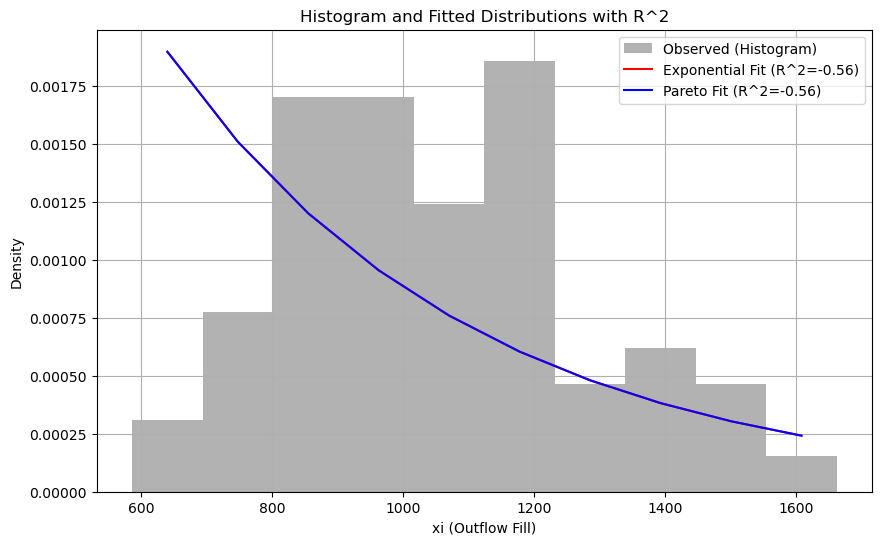

In [63]:
# R^2 and plot

# Histogram for observed densities
hist, bin_edges = np.histogram(xi_data, bins=10, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Compute bin centers

# Predicted densities from fitted distributions
exp_pdf = expon.pdf(bin_centers, loc=exp_loc, scale=exp_scale)
pareto_pdf = pareto.pdf(bin_centers, b=pareto_shape, loc=pareto_loc, scale=pareto_scale)

# Calculate R^2 for Exponential
rss_exp = np.sum((hist - exp_pdf) ** 2)
tss = np.sum((hist - np.mean(hist)) ** 2)
r2_exp = 1 - (rss_exp / tss)

# Calculate R^2 for Pareto
rss_pareto = np.sum((hist - pareto_pdf) ** 2)
r2_pareto = 1 - (rss_pareto / tss)

# Calculate R^2 for Poisson
x_values = np.arange(0, max(xi_data) + 1)
pmf_values = poisson_dist.pmf(x_values)
observed_frequencies, bins = np.histogram(xi_data, bins=np.arange(0, max(xi_data) + 2) - 0.5)
expected_frequencies = pmf_values * len(xi_data)
rss = np.sum((observed_frequencies - expected_frequencies) ** 2)  # Residual Sum of Squares
tss = np.sum((observed_frequencies - np.mean(observed_frequencies)) ** 2)  # Total Sum of Squares
r2_poisson = 1 - (rss / tss)

# Print R^2 results
print("R^2 for Exponential Distribution:", r2_exp)
print("R^2 for Pareto Distribution:", r2_pareto)
print("R^2 for Poisson Distribution:", r2_poisson)

# Plot results
plt.figure(figsize=(10, 6))
plt.hist(xi_data, bins=10, density=True, alpha=0.6, color='gray', label='Observed (Histogram)')
plt.plot(bin_centers, exp_pdf, 'r-', label=f'Exponential Fit (R^2={r2_exp:.2f})')
plt.plot(bin_centers, pareto_pdf, 'b-', label=f'Pareto Fit (R^2={r2_pareto:.2f})')
plt.xlabel('xi (Outflow Fill)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.title("Histogram and Fitted Distributions with R^2")
plt.show()

The result above is generated by simulated data.